# Practical Machine Learning – M4 Practice Hackathon
### Loan Default Classification (F1 Optimization)

This notebook builds and validates a **well-fit** classifier for the loan default dataset and generates a Kaggle-ready `submit.csv`.

**Key goals (per assignment):**
- Maximize **F1-score** (competition metric)
- Use a strong **validation strategy** (Stratified K-Fold CV)
- Compare **≥ 3 models**
- Address **class imbalance** (class weights / scale_pos_weight / threshold tuning)
- Assess fit (learning curve, confusion matrix, precision–recall)


In [ ]:

# --- Setup ---》
import numpy as np
import pandas as pd
!pip install lightgbm xgboost catboost --quiet
from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV, learning_curve
from sklearn.metrics import f1_score, precision_recall_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

# Gradient boosting libraries
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42

# Paths (already uploaded in this environment)
TRAIN_PATH = r"C:\Users\daisy0527\Desktop\practical machine learning\M4prctice\loan_train.csv"
TEST_PATH = r"C:\Users\daisy0527\Desktop\practical machine learning\M4prctice\loan_test.csv"
SAMPLE_SUB_PATH = r"C:\Users\daisy0527\Desktop\practical machine learning\M4prctice\sample_submission.csv"

In [4]:

# --- Load data ---
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Sample submission shape:", sample_sub.shape)

train_df.head()


Train shape: (36000, 14)
Test shape : (9000, 13)
Sample submission shape: (3, 2)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,24.0,male,Master,58914.0,2,OWN,4400.0,VENTURE,5.99,0.07,4.0,656,Yes,0
1,23.0,female,High School,45873.0,2,RENT,11000.0,VENTURE,11.01,0.24,2.0,634,Yes,0
2,29.0,female,Master,240947.0,7,MORTGAGE,10000.0,VENTURE,12.69,0.04,9.0,638,Yes,0
3,30.0,female,Bachelor,96316.0,10,MORTGAGE,6000.0,MEDICAL,13.49,0.06,8.0,682,No,0
4,29.0,male,Bachelor,73033.0,7,MORTGAGE,8000.0,PERSONAL,10.51,0.11,8.0,644,Yes,0


## 1) Quick EDA (sanity checks)

We check:
- target balance (class imbalance)
- missing values
- basic distribution ranges


In [5]:

# Target balance
target_col = "loan_status"
y = train_df[target_col].astype(int)
X = train_df.drop(columns=[target_col])

print("Class balance (0=non-default, 1=default):")
display(y.value_counts())
display((y.value_counts(normalize=True)*100).round(2).rename("percent"))

# Missing values
print("\nMissing values (train):")
display(train_df.isna().sum().to_frame("n_missing").T)

print("\nMissing values (test):")
display(test_df.isna().sum().to_frame("n_missing").T)

# Basic stats for numeric columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]
print("\nNumeric columns:", num_cols)
print("Categorical columns:", cat_cols)

X[num_cols].describe().T


Class balance (0=non-default, 1=default):


loan_status
0    28000
1     8000
Name: count, dtype: int64

loan_status
0    77.78
1    22.22
Name: percent, dtype: float64


Missing values (train):


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
n_missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Missing values (test):


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
n_missing,0,0,0,0,0,0,0,0,0,0,0,0,0



Numeric columns: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
Categorical columns: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


,count,mean,std,min,25%,50%,75%,max
person_age,36000.0,27.763194,6.045354,20.00,24.00,26.00,30.0000,144.00
person_income,36000.0,80549.469361,84316.972457,8000.00,47163.50,67081.00,96260.7500,7200766.00
person_emp_exp,36000.0,5.405611,6.064240,0.00,1.00,4.00,8.0000,125.00
loan_amnt,36000.0,9586.962861,6301.447426,500.00,5000.00,8000.00,12235.0000,35000.00
loan_int_rate,36000.0,11.013158,2.976288,5.42,8.59,11.01,13.0225,20.00
loan_percent_income,36000.0,0.139635,0.086949,0.00,0.07,0.12,0.1900,0.66
cb_person_cred_hist_length,36000.0,5.863444,3.878709,2.00,3.00,4.00,8.0000,30.00
credit_score,36000.0,632.649583,50.292346,390.00,602.00,640.00,670.0000,850.00


## 2) Preprocessing

- **Categorical**: OneHotEncode (handle_unknown='ignore')
- **Numeric**: (optional scaling for Logistic Regression); for tree models scaling is not required but is harmless.
- No missing values in this dataset, but we keep imputers for robustness.


In [6]:

# Preprocessing blocks
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

# Compute imbalance ratio for weighting
n_pos = int((y == 1).sum())
n_neg = int((y == 0).sum())
pos_weight = n_neg / max(n_pos, 1)
print("pos_weight (neg/pos) =", pos_weight)


pos_weight (neg/pos) = 3.5


## 3) Light feature engineering (domain-inspired)

Credit-risk data is often driven by **ratios** and **nonlinearities**.  
We create a few safe ratio features that usually help with F1:

- `loan_to_income = loan_amnt / (person_income + 1)`
- `interest_x_loanpct = loan_int_rate * loan_percent_income`
- `cred_hist_to_age = cb_person_cred_hist_length / (person_age + 1)`


In [7]:

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["loan_to_income"] = df["loan_amnt"] / (df["person_income"] + 1.0)
    df["interest_x_loanpct"] = df["loan_int_rate"] * df["loan_percent_income"]
    df["cred_hist_to_age"] = df["cb_person_cred_hist_length"] / (df["person_age"] + 1.0)
    return df

X_fe = add_features(X)
test_fe = add_features(test_df)

# Update column lists
num_cols_fe = X_fe.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_fe = [c for c in X_fe.columns if c not in num_cols_fe]

print("Added features:", [c for c in X_fe.columns if c not in X.columns])
print("Now numeric columns:", len(num_cols_fe), "categorical columns:", len(cat_cols_fe))


Added features: ['loan_to_income', 'interest_x_loanpct', 'cred_hist_to_age']
Now numeric columns: 11 categorical columns: 5


In [8]:

# Rebuild preprocess with engineered columns
numeric_transformer_fe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_fe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_fe = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_fe, num_cols_fe),
        ("cat", categorical_transformer_fe, cat_cols_fe),
    ],
    remainder="drop"
)


## 4) Validation strategy: Stratified K-Fold CV

We use **StratifiedKFold** so each fold preserves the class ratio.
We evaluate using **F1-score**, aligned with Kaggle.


In [9]:

from sklearn.base import clone

def cv_f1(model, X, y, preprocess, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    f1s = []
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        pipe = Pipeline([("preprocess", preprocess), ("model", clone(model))])
        pipe.fit(X_tr, y_tr)
        preds = pipe.predict(X_va)
        f1 = f1_score(y_va, preds)
        f1s.append(f1)
        print(f"Fold {fold}: F1 = {f1:.4f}")
    print(f"\nMean F1: {np.mean(f1s):.4f}  |  Std: {np.std(f1s):.4f}")
    return np.array(f1s)

X_use = X_fe
y_use = y


## 5) Model comparison (≥ 3 models)

We compare:
1. **Logistic Regression** (baseline, interpretable)
2. **Random Forest** (nonlinear baseline)
3. **LightGBM** (strong GBDT baseline)
4. **XGBoost** (strong GBDT baseline)
5. **CatBoost** (strong GBDT, handles categorical well; we still use one-hot for consistency)

We also enable imbalance handling via:
- `class_weight="balanced"` (LogReg / RF)
- `scale_pos_weight` (XGB)
- `class_weight` (LGBM)


In [10]:

logreg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="lbfgs"
)

rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lgbm = LGBMClassifier(
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

xgb = XGBClassifier(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    reg_alpha=0.0,
    min_child_weight=1.0,
    gamma=0.0,
    scale_pos_weight=pos_weight,
    eval_metric="logloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cat = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=RANDOM_STATE,
    verbose=False
)

print("LogReg CV:")
f1_logreg = cv_f1(logreg, X_use, y_use, preprocess_fe)

print("\nRandomForest CV:")
f1_rf = cv_f1(rf, X_use, y_use, preprocess_fe)

print("\nLightGBM CV:")
f1_lgbm = cv_f1(lgbm, X_use, y_use, preprocess_fe)

print("\nXGBoost CV:")
f1_xgb = cv_f1(xgb, X_use, y_use, preprocess_fe)

print("\nCatBoost CV:")
f1_cat = cv_f1(cat, X_use, y_use, preprocess_fe)


LogReg CV:
Fold 1: F1 = 0.7441
Fold 2: F1 = 0.7319
Fold 3: F1 = 0.7387
Fold 4: F1 = 0.7413
Fold 5: F1 = 0.7457

Mean F1: 0.7403  |  Std: 0.0049

RandomForest CV:
Fold 1: F1 = 0.8242
Fold 2: F1 = 0.8217
Fold 3: F1 = 0.8467
Fold 4: F1 = 0.8262
Fold 5: F1 = 0.8383

Mean F1: 0.8314  |  Std: 0.0096

LightGBM CV:


E:\software\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "E:\software\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "E:\software\anaconda\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "E:\software\anaconda\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                      

[LightGBM] [Info] Number of positive: 6400, number of negative: 22400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001882 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1944
[LightGBM] [Info] Number of data points in the train set: 28800, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


E:\software\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1: F1 = 0.8354
[LightGBM] [Info] Number of positive: 6400, number of negative: 22400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001245 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1948
[LightGBM] [Info] Number of data points in the train set: 28800, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


...

Fold 3: F1 = 0.8471
[LightGBM] [Info] Number of positive: 6400, number of negative: 22400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001421 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1948
[LightGBM] [Info] Number of data points in the train set: 28800, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


E:\software\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4: F1 = 0.8375
[LightGBM] [Info] Number of positive: 6400, number of negative: 22400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001289 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1945
[LightGBM] [Info] Number of data points in the train set: 28800, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


E:\software\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 5: F1 = 0.8416

Mean F1: 0.8386  |  Std: 0.0054

XGBoost CV:
Fold 1: F1 = 0.8351
Fold 2: F1 = 0.8220
Fold 3: F1 = 0.8401
Fold 4: F1 = 0.8332
Fold 5: F1 = 0.8329

Mean F1: 0.8327  |  Std: 0.0059

CatBoost CV:
Fold 1: F1 = 0.8389
Fold 2: F1 = 0.8399
Fold 3: F1 = 0.8545
Fold 4: F1 = 0.8368
Fold 5: F1 = 0.8487

Mean F1: 0.8438  |  Std: 0.0068


## 6) Hyperparameter tuning (focused)

We tune the best-performing gradient boosting model with **RandomizedSearchCV** (efficient vs grid search).
We optimize **F1** under **Stratified K-Fold**.

> Tip: You can increase `n_iter` and `cv` if you have more compute budget.


In [11]:

# Choose which model to tune. In many runs, LightGBM or XGBoost tends to win.
# We'll tune LightGBM as a strong default; switch to XGB if it outperforms on your CV above.
base_model = LGBMClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

pipe = Pipeline([
    ("preprocess", preprocess_fe),
    ("model", base_model)
])

param_dist = {
    "model__n_estimators": np.arange(600, 2600, 200),
    "model__learning_rate": np.linspace(0.01, 0.08, 16),
    "model__num_leaves": np.arange(16, 128, 8),
    "model__max_depth": [-1, 3, 4, 5, 6, 7, 8],
    "model__min_child_samples": np.arange(10, 120, 10),
    "model__subsample": np.linspace(0.6, 1.0, 9),
    "model__colsample_bytree": np.linspace(0.6, 1.0, 9),
    "model__reg_alpha": np.linspace(0.0, 2.0, 9),
    "model__reg_lambda": np.linspace(0.0, 4.0, 9),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,               # increase if you want more search
    scoring="f1",
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

search.fit(X_use, y_use)

print("Best CV F1:", search.best_score_)
print("Best params:")
display(search.best_params_)

best_pipe = search.best_estimator_


Fitting 5 folds for each of 40 candidates, totalling 200 fits
[LightGBM] [Info] Number of positive: 8000, number of negative: 28000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001875 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1952
[LightGBM] [Info] Number of data points in the train set: 36000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

{'model__subsample': np.float64(0.85),
 'model__reg_lambda': np.float64(1.5),
 'model__reg_alpha': np.float64(0.75),
 'model__num_leaves': np.int64(96),
 'model__n_estimators': np.int64(1800),
 'model__min_child_samples': np.int64(20),
 'model__max_depth': -1,
 'model__learning_rate': np.float64(0.07066666666666667),
 'model__colsample_bytree': np.float64(0.75)}

## 7) Threshold tuning (often boosts F1)

Kaggle submissions use hard labels, but our model produces probabilities.  
Instead of the default threshold 0.50, we find a threshold that maximizes **F1** using out-of-fold (OOF) probabilities.


Best OOF threshold: 0.6649999999999999
Best OOF F1: 0.8465291783228157


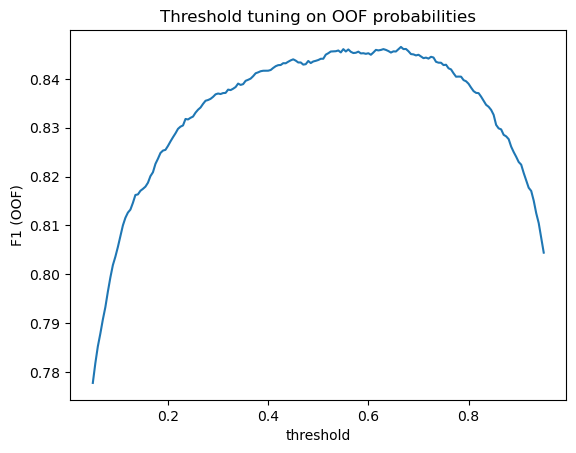

In [12]:

from sklearn.model_selection import cross_val_predict

# Get out-of-fold predicted probabilities for class 1
oof_proba = cross_val_predict(
    best_pipe, X_use, y_use,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

thresholds = np.linspace(0.05, 0.95, 181)
f1s = []
for t in thresholds:
    pred = (oof_proba >= t).astype(int)
    f1s.append(f1_score(y_use, pred))

best_t = thresholds[int(np.argmax(f1s))]
best_f1 = float(np.max(f1s))
print("Best OOF threshold:", best_t)
print("Best OOF F1:", best_f1)

plt.figure()
plt.plot(thresholds, f1s)
plt.xlabel("threshold")
plt.ylabel("F1 (OOF)")
plt.title("Threshold tuning on OOF probabilities")
plt.show()


## 8) Fit assessment: holdout diagnostics (confusion matrix, PR curve, learning curve)

We keep this section **diagnostic** (not for final score), to interpret business trade-offs:
- Confusion matrix
- Precision–Recall curve
- Learning curve (overfit / underfit check)


[LightGBM] [Info] Number of positive: 6400, number of negative: 22400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000936 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1952
[LightGBM] [Info] Number of data points in the train set: 28800, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

E:\software\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Holdout F1 (threshold-tuned): 0.8417289567760806

Classification report:
              precision    recall  f1-score   support

           0     0.9467    0.9675    0.9570      5600
           1     0.8768    0.8094    0.8417      1600

    accuracy                         0.9324      7200
   macro avg     0.9117    0.8884    0.8994      7200
weighted avg     0.9312    0.9324    0.9314      7200



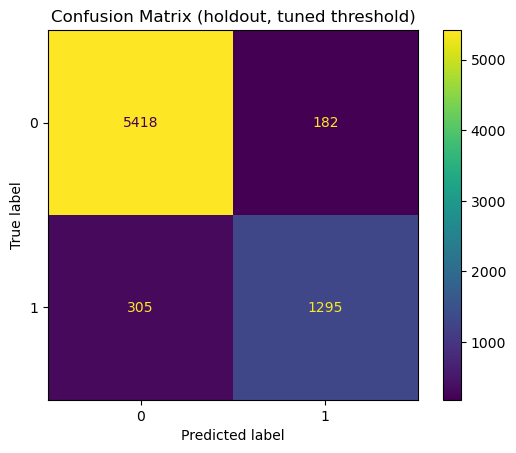

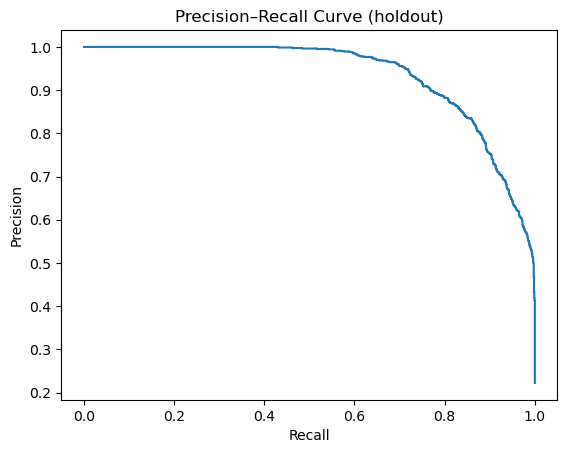

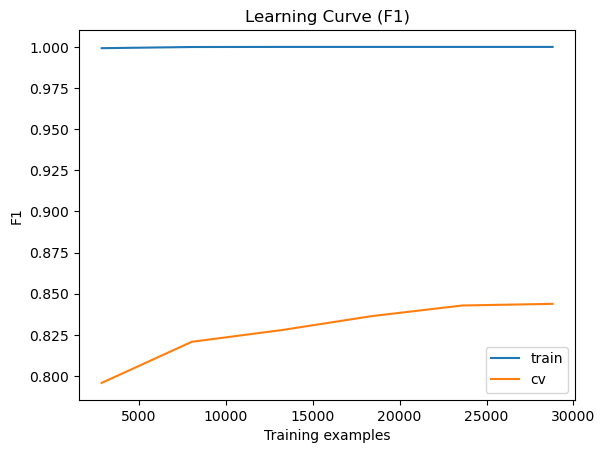

In [13]:

# Holdout split for diagnostics (not used for final training)
X_tr, X_va, y_tr, y_va = train_test_split(
    X_use, y_use, test_size=0.2, stratify=y_use, random_state=RANDOM_STATE
)

best_pipe.fit(X_tr, y_tr)
va_proba = best_pipe.predict_proba(X_va)[:, 1]
va_pred = (va_proba >= best_t).astype(int)

print("Holdout F1 (threshold-tuned):", f1_score(y_va, va_pred))
print("\nClassification report:")
print(classification_report(y_va, va_pred, digits=4))

cm = confusion_matrix(y_va, va_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (holdout, tuned threshold)")
plt.show()

prec, rec, thr = precision_recall_curve(y_va, va_proba)
plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (holdout)")
plt.show()

# Learning curve (can take a bit; reduce train_sizes if needed)
train_sizes, train_scores, val_scores = learning_curve(
    best_pipe, X_use, y_use,
    cv=cv, scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 6),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="train")
plt.plot(train_sizes, val_mean, label="cv")
plt.xlabel("Training examples")
plt.ylabel("F1")
plt.title("Learning Curve (F1)")
plt.legend()
plt.show()


## 9) Train on full training set + Generate Kaggle submission

We fit the tuned pipeline on **all** training data and predict the test set.
We apply the tuned threshold and write `submit.csv` in Kaggle format.


In [18]:
print([name for name in globals().keys() if "test" in name.lower()])
# Fit on full data
best_pipe.fit(X_use, y_use)

test_proba = best_pipe.predict_proba(test_fe)[:, 1]
test_pred = (test_proba >= best_t).astype(int)

# 取 test 的 id
test_ids = test_df["id"].copy() if "id" in test_df.columns else pd.Series(range(len(test_df)))

# 生成 submission
submission = pd.DataFrame({
    "id": test_ids,
    "loan_status": test_pred.astype(int)
})

# 保存到你当前文件夹（建议就存同目录）
submission.to_csv("submit.csv", index=False)

print(submission.shape)
submission.head()


['train_test_split', 'TEST_PATH', 'test_df', 'test_fe', 'test_proba', 'test_pred', 'test_ids']
[LightGBM] [Info] Number of positive: 8000, number of negative: 28000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000504 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1952
[LightGBM] [Info] Number of data points in the train set: 36000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

E:\software\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


(9000, 2)


,id,loan_status
0,0,0
1,1,0
2,2,0
3,3,0
4,4,1


## Notes for your discussion video (quick checklist)

- **What improved performance?**
  - Ratio features (loan_to_income, interest_x_loanpct, cred_hist_to_age)
  - Switching from linear baseline (LogReg) to gradient boosting (LGBM/XGB/Cat)
  - Handling imbalance via class weights / scale_pos_weight
  - Hyperparameter tuning via RandomizedSearchCV
  - Threshold tuning for F1

- **Fit/validation**
  - Stratified 5-fold CV for stable estimates
  - Learning curve + holdout confusion matrix + PR curve for diagnostics
  - Business: FN (missed default) vs FP (unnecessarily rejecting good borrowers)

- **If more time**
  - More feature engineering (binning credit_score, interactions)
  - Stacking/ensembling
  - Monitoring & drift detection in production
